# N and M Tuning — Reservoir Size
Exploring how the number of loops (N) and probes (M) affect reservoir performance.

**N** = number of interference loops (whirlpools). Currently 500.
- More loops → richer reservoir state → potentially better performance
- But at what point do we hit diminishing returns?

**M** = number of probe electrodes (buoys). Currently 20.
- More probes → more readout information → potentially better performance
- But more probes also means more hardware in a real device

We test N and M independently to see which one matters more and where the minimum useful size is.

---
Note: tau ∈ [1,15] and alpha ~ N(0,1) are fixed at their optimal values from prior experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Utility functions

In [2]:
def ridge_regression(X_train, y_train, X_test, beta=1e-6):
    I = np.eye(X_train.shape[1])
    W = np.linalg.solve(X_train.T @ X_train + beta * I, X_train.T @ y_train)
    return X_test @ W, W


def generate_narma10(u):
    T = len(u)
    y = np.zeros(T)
    for t in range(10, T - 1):
        y[t + 1] = (
            0.3 * y[t]
            + 0.05 * y[t] * np.sum(y[t - 9:t + 1])
            + 1.5 * u[t - 9] * u[t]
            + 0.1
        )
    return y


def memory_capacity(u, X, delays, washout=500, train_len=2500, test_len=2000):
    mc = []
    for d in delays:
        X_train = X[washout + d : washout + train_len]
        y_train = u[washout : washout + train_len - d]
        X_test  = X[washout + train_len : washout + train_len + test_len]
        y_test  = u[washout + train_len - d : washout + train_len + test_len - d]
        y_pred, _ = ridge_regression(X_train, y_train, X_test)
        corr  = np.corrcoef(y_pred.ravel(), y_test.ravel())[0, 1]
        mc.append(0.0 if np.isnan(corr) else corr**2)
    return np.array(mc)


def narma10_nmse(u, X, washout=500, train_len=2500, test_len=2000):
    y       = generate_narma10(u)
    X_train = X[washout : washout + train_len]
    y_train = y[washout : washout + train_len]
    X_test  = X[washout + train_len : washout + train_len + test_len]
    y_test  = y[washout + train_len : washout + train_len + test_len]
    _, Wout     = ridge_regression(X_train, y_train, X_train)
    y_pred_test = X_test @ Wout
    return np.mean((y_pred_test - y_test)**2) / np.var(y_test)


def simulate_reservoir(T=6000, N=500, M=20, dt=1.0, seed=7):
    """Fixed reservoir (delta-s), tau in [1,15], alpha ~ N(0,1)."""
    rng   = np.random.default_rng(seed)
    u     = rng.uniform(0.0, 0.5, size=T)
    A     = rng.uniform(0.5, 1.5, size=N)
    alpha = rng.normal(0.0, 1.0, size=N)
    tau   = rng.integers(1, 16, size=N).astype(float)
    lam   = np.exp(-dt / tau)
    phi   = rng.uniform(0, 2 * np.pi, size=N)
    Wmix  = rng.normal(0.0, 1.0 / np.sqrt(N), size=(M, N))

    s = np.zeros(N)
    R = np.zeros((T, M))
    for t in range(T):
        s_prev  = s.copy()
        s       = lam * s + (1.0 - lam) * u[t]
        delta_s = s - s_prev
        phi     = phi + alpha * delta_s * dt
        g       = A * np.cos(phi)
        R[t, :] = Wmix @ g
    return u, R

## Part 1 — Sweep N (number of loops), fix M=20

In [3]:
delays   = np.arange(1, 41)
N_values = [50, 100, 200, 500, 1000]

N_results = []
for N in N_values:
    u, R = simulate_reservoir(N=N, M=20)
    X    = np.hstack([R, np.ones((R.shape[0], 1))])
    mc   = memory_capacity(u, X, delays)
    nmse = narma10_nmse(u, X)
    N_results.append({"label": f"N={N}", "mc": mc, "nmse": nmse})
    print(f"N={N:4d}, M=20   |  Total MC = {mc.sum():.2f}  |  NARMA10 NMSE = {nmse:.4f}")

N=  50, M=20   |  Total MC = 4.76  |  NARMA10 NMSE = 0.2991
N= 100, M=20   |  Total MC = 4.78  |  NARMA10 NMSE = 0.2986
N= 200, M=20   |  Total MC = 4.73  |  NARMA10 NMSE = 0.2989
N= 500, M=20   |  Total MC = 4.86  |  NARMA10 NMSE = 0.2982
N=1000, M=20   |  Total MC = 4.86  |  NARMA10 NMSE = 0.2990


## Part 2 — Sweep M (number of probes), fix N=500

In [4]:
M_values = [5, 10, 20, 50, 100]

M_results = []
for M in M_values:
    u, R = simulate_reservoir(N=500, M=M)
    X    = np.hstack([R, np.ones((R.shape[0], 1))])
    mc   = memory_capacity(u, X, delays)
    nmse = narma10_nmse(u, X)
    M_results.append({"label": f"M={M}", "mc": mc, "nmse": nmse})
    print(f"N=500, M={M:3d}   |  Total MC = {mc.sum():.2f}  |  NARMA10 NMSE = {nmse:.4f}")

N=500, M=  5   |  Total MC = 2.27  |  NARMA10 NMSE = 0.4723
N=500, M= 10   |  Total MC = 3.74  |  NARMA10 NMSE = 0.3479
N=500, M= 20   |  Total MC = 4.86  |  NARMA10 NMSE = 0.2982
N=500, M= 50   |  Total MC = 5.10  |  NARMA10 NMSE = 0.2981
N=500, M=100   |  Total MC = 5.23  |  NARMA10 NMSE = 0.2981


## Plot results

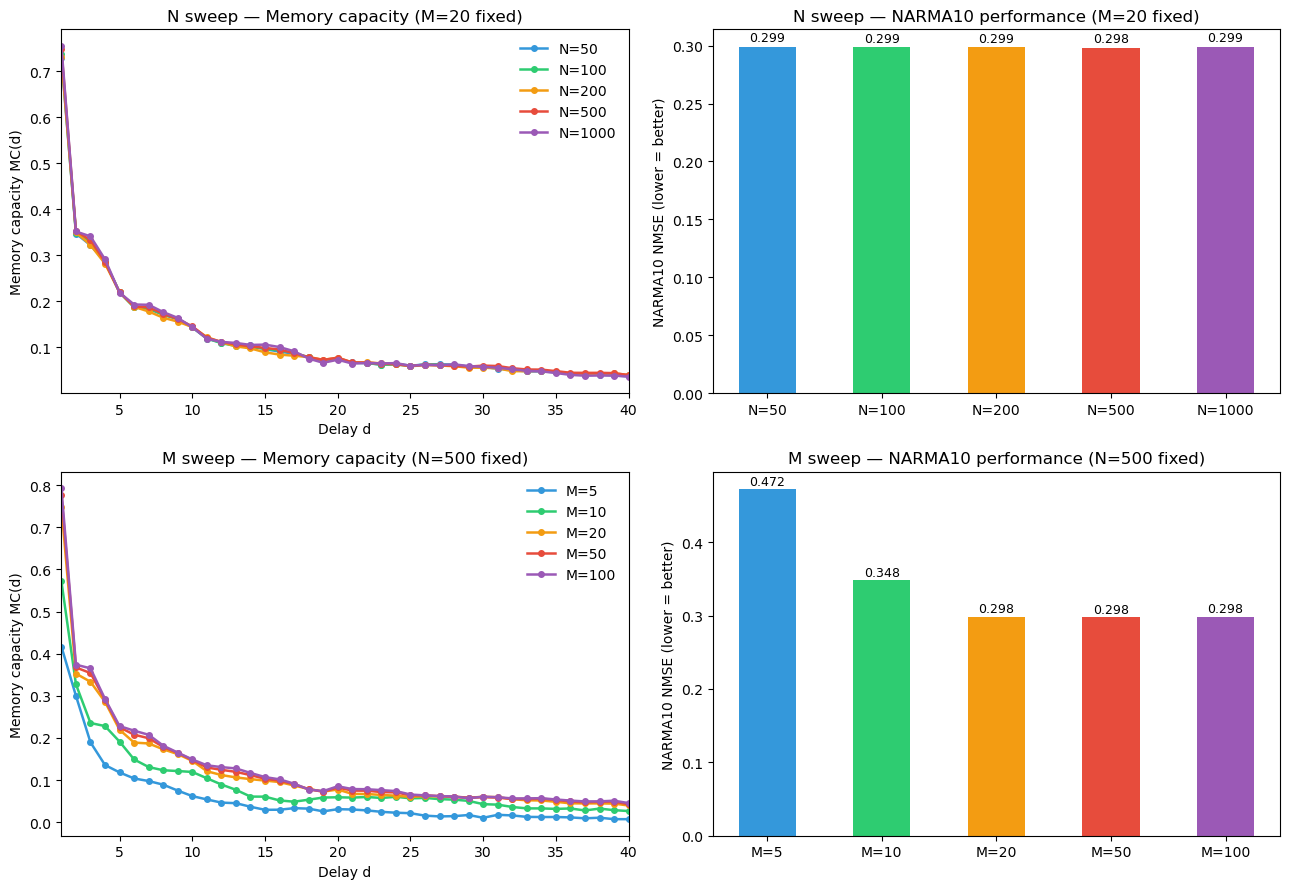

In [5]:
colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Row 1: N sweep ---
for res, color in zip(N_results, colors):
    axes[0, 0].plot(delays, res["mc"], 'o-', lw=1.8, ms=4, color=color, label=res["label"])
axes[0, 0].set_xlabel("Delay d")
axes[0, 0].set_ylabel("Memory capacity MC(d)")
axes[0, 0].set_title("N sweep — Memory capacity (M=20 fixed)")
axes[0, 0].set_xlim(delays.min(), delays.max())
axes[0, 0].legend(frameon=False)

N_labels = [r["label"] for r in N_results]
N_nmses  = [r["nmse"] for r in N_results]
bars = axes[0, 1].bar(N_labels, N_nmses, color=colors, width=0.5)
axes[0, 1].set_ylabel("NARMA10 NMSE (lower = better)")
axes[0, 1].set_title("N sweep — NARMA10 performance (M=20 fixed)")
for bar, val in zip(bars, N_nmses):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}",
                    ha='center', va='bottom', fontsize=9)

# --- Row 2: M sweep ---
for res, color in zip(M_results, colors):
    axes[1, 0].plot(delays, res["mc"], 'o-', lw=1.8, ms=4, color=color, label=res["label"])
axes[1, 0].set_xlabel("Delay d")
axes[1, 0].set_ylabel("Memory capacity MC(d)")
axes[1, 0].set_title("M sweep — Memory capacity (N=500 fixed)")
axes[1, 0].set_xlim(delays.min(), delays.max())
axes[1, 0].legend(frameon=False)

M_labels = [r["label"] for r in M_results]
M_nmses  = [r["nmse"] for r in M_results]
bars = axes[1, 1].bar(M_labels, M_nmses, color=colors, width=0.5)
axes[1, 1].set_ylabel("NARMA10 NMSE (lower = better)")
axes[1, 1].set_title("M sweep — NARMA10 performance (N=500 fixed)")
for bar, val in zip(bars, M_nmses):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("NM_tuning.png", dpi=300, bbox_inches="tight")
plt.show()